In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import griddata
import contextily as ctx
from pyproj import Transformer
import warnings
warnings.filterwarnings('ignore')

In [60]:
df = pd.read_csv("../abm/data/ghana_data.csv")

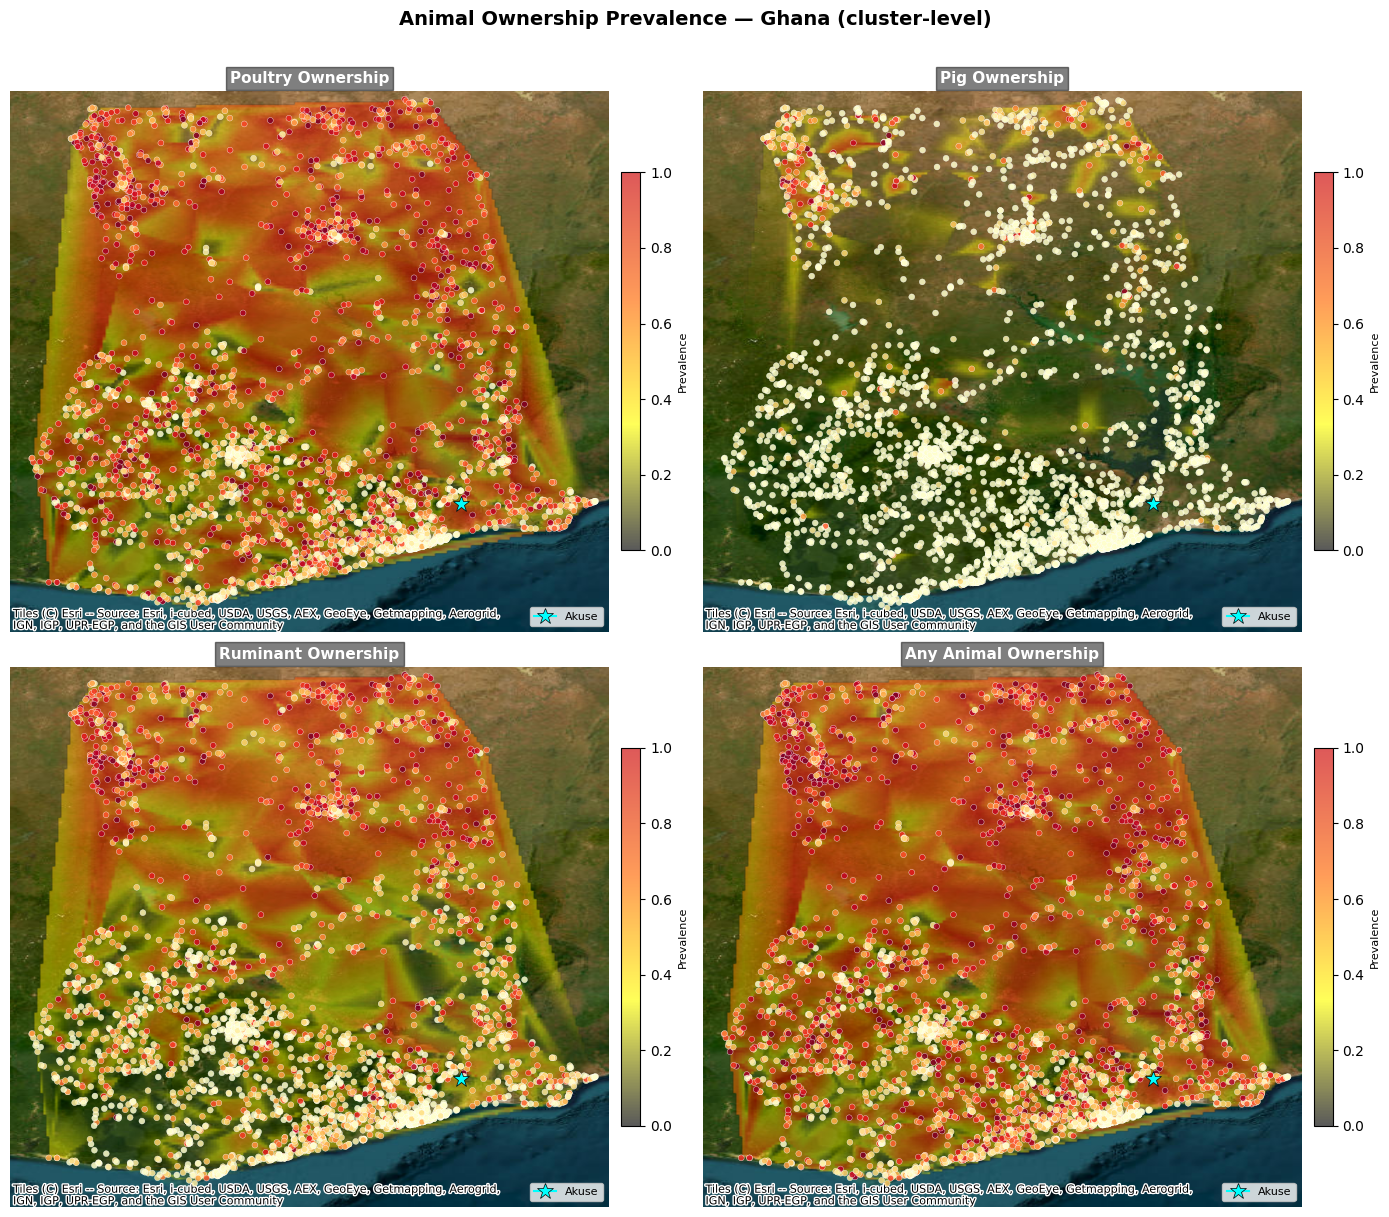

In [ ]:
# ── 1. Encode string → binary ─────────────────────────────────────────────────
df['Poultry_bin']  = df['Poultry'].str.contains('Yes', case=False, na=False).astype(int)
df['Pigs_bin']     = df['Pigs'].str.contains('Yes', case=False, na=False).astype(int)
df['Ruminant_bin'] = df['Ruminant'].str.contains('Yes', case=False, na=False).astype(int)

# ── 2. Cluster-level prevalence ───────────────────────────────────────────────
animal_cols = ['Poultry_bin', 'Pigs_bin', 'Ruminant_bin']
cluster_stats = (
    df.groupby(['Cluster', 'Latitude', 'Longitude'])[animal_cols]
    .mean()
    .reset_index()
)
cluster_stats['Any_Animal'] = cluster_stats[animal_cols].max(axis=1)


rural_mask = df['URBAN'].astype(str).str.contains('Rural', case=False, na=False)
cluster_stats = (
    df[rural_mask]
    .groupby(['Cluster', 'Latitude', 'Longitude'])[animal_cols + feature_cols]
    .mean()
    .reset_index()
)
print(f"Rural clusters: {len(cluster_stats)}")

# ── 3. Reproject to Web Mercator (EPSG:3857) for contextily ──────────────────
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x, y = transformer.transform(
    cluster_stats['Longitude'].values,
    cluster_stats['Latitude'].values
)
cluster_stats['x'] = x
cluster_stats['y'] = y

# ── 4. Ghana bounding box in Web Mercator ────────────────────────────────────
lon_min, lon_max = -3.4, 1.3
lat_min, lat_max =  4.5, 11.2
x_min, y_min = transformer.transform(lon_min, lat_min)
x_max, y_max = transformer.transform(lon_max, lat_max)

# ── 5. Interpolation grid ─────────────────────────────────────────────────────
grid_res = 200
xi = np.linspace(x_min, x_max, grid_res)
yi = np.linspace(y_min, y_max, grid_res)
Xi, Yi = np.meshgrid(xi, yi)

# ── 6. Plot — one panel per animal type + combined ───────────────────────────
plot_cols = {
    'Poultry_bin':  'Poultry Ownership',
    'Pigs_bin':     'Pig Ownership',
    'Ruminant_bin': 'Ruminant Ownership',
    'Any_Animal':   'Any Animal Ownership',
}

cmap = mcolors.LinearSegmentedColormap.from_list(
    'animal', ['#00000000', '#ffff00aa', '#ff6600cc', '#cc0000ee']
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (col, title) in zip(axes, plot_cols.items()):
    # Interpolate prevalence onto grid
    zi = griddata(
        points=(cluster_stats['x'].values, cluster_stats['y'].values),
        values=cluster_stats[col].values,
        xi=(Xi, Yi),
        method='linear'
    )

    # Satellite basemap
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, zoom=7, crs='EPSG:3857')

    # Heatmap overlay
    im = ax.imshow(
        zi,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap=cmap,
        vmin=0, vmax=1,
        alpha=0.65,
        aspect='auto',
        zorder=2
    )

    # Cluster scatter
    ax.scatter(cluster_stats['x'], cluster_stats['y'],
               c=cluster_stats[col], cmap='YlOrRd',
               s=18, edgecolors='white', linewidths=0.3,
               vmin=0, vmax=1, zorder=3, alpha=0.85)

    # Akuse marker
    ax_lon, ax_lat = 0.1390, 6.0906
    ax_x, ax_y = transformer.transform(ax_lon, ax_lat)
    ax.plot(ax_x, ax_y, marker='*', color='cyan', markersize=12,
            markeredgecolor='black', markeredgewidth=0.5, zorder=4, label='Akuse')
    ax.legend(loc='lower right', fontsize=8)

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Prevalence', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold', color='white',
                 bbox=dict(facecolor='black', alpha=0.5, pad=3))
    ax.axis('off')

fig.suptitle('Animal Ownership Prevalence — Ghana (cluster-level)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

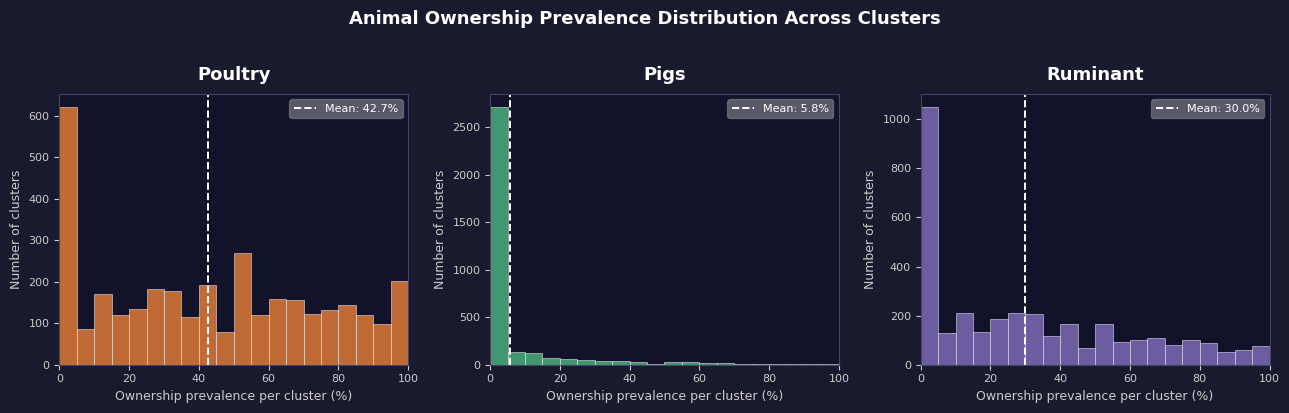

In [56]:
# ── Encode string → binary ────────────────────────────────────────────────
df['Poultry_bin']  = df['Poultry'].str.contains('Yes', case=False, na=False).astype(int)
df['Pigs_bin']     = df['Pigs'].str.contains('Yes', case=False, na=False).astype(int)
df['Ruminant_bin'] = df['Ruminant'].str.contains('Yes', case=False, na=False).astype(int)

# ── Cluster-level prevalence ──────────────────────────────────────────────
animal_cols = ['Poultry_bin', 'Pigs_bin', 'Ruminant_bin']
cluster_stats = (
    df.groupby(['Cluster', 'Latitude', 'Longitude'])[animal_cols]
    .mean()
    .reset_index()
)

# ── Plot ──────────────────────────────────────────────────────────────────
colors = {'Poultry_bin': '#e07b39', 'Pigs_bin': '#4caf7d', 'Ruminant_bin': '#7b6bb5'}
labels = {'Poultry_bin': 'Poultry', 'Pigs_bin': 'Pigs', 'Ruminant_bin': 'Ruminant'}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.patch.set_facecolor('#1a1a2e')

for ax, col in zip(axes, animal_cols):
    data = cluster_stats[col] * 100
    color = colors[col]

    counts, edges = np.histogram(data, bins=20, range=(0, 100))
    ax.bar(edges[:-1], counts, width=np.diff(edges), color=color,
           alpha=0.85, edgecolor='white', linewidth=0.4, align='edge')

    mean_val = data.mean()
    ax.axvline(mean_val, color='white', linestyle='--', linewidth=1.4, label=f'Mean: {mean_val:.1f}%')

    ax.set_facecolor('#12122a')
    ax.set_title(labels[col], fontsize=13, fontweight='bold', color='white', pad=10)
    ax.set_xlabel('Ownership prevalence per cluster (%)', fontsize=9, color='#cccccc')
    ax.set_ylabel('Number of clusters', fontsize=9, color='#cccccc')
    ax.tick_params(colors='#cccccc', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')
    ax.legend(fontsize=8, framealpha=0.3, labelcolor='white')
    ax.set_xlim(0, 100)

fig.suptitle('Animal Ownership Prevalence Distribution Across Clusters',
             fontsize=13, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()


Rural clusters: 1806
Best radius: 3.0° (~333 km)

MAE at best radius:
Poultry_bin     0.213
Pigs_bin        0.099
Ruminant_bin    0.192
Name: 3.0, dtype: float64


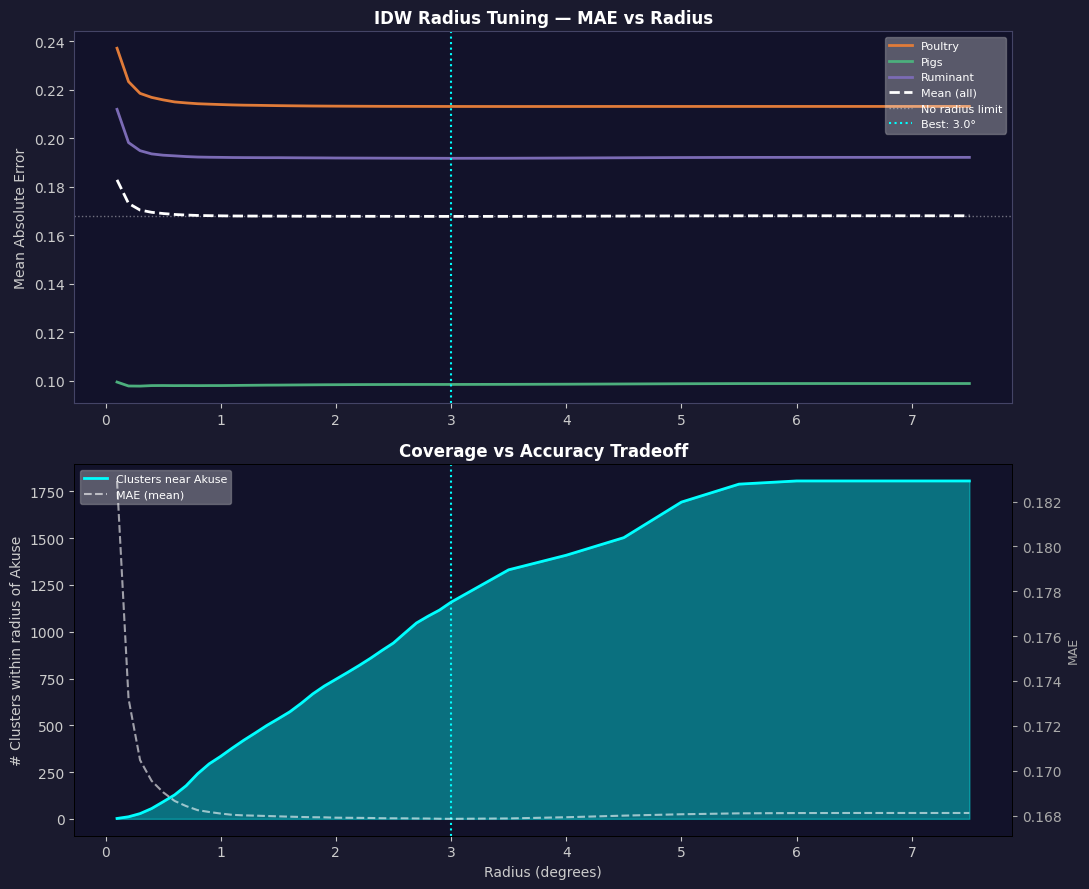


── Akuse Prevalence Estimates ──────────────────────────
  Poultry   : 0.535  ±0.213  (95% CI: [0.108, 0.961])
  Pigs      : 0.012  ±0.099  (95% CI: [0.000, 0.209])
  Ruminant  : 0.327  ±0.192  (95% CI: [0.000, 0.710])


In [ ]:
# ── Encode string → binary ────────────────────────────────────────────────
df['Poultry_bin']  = df['Poultry'].str.contains('Yes', case=False, na=False).astype(int)
df['Pigs_bin']     = df['Pigs'].str.contains('Yes', case=False, na=False).astype(int)
df['Ruminant_bin'] = df['Ruminant'].str.contains('Yes', case=False, na=False).astype(int)

animal_cols  = ['Poultry_bin', 'Pigs_bin', 'Ruminant_bin']
feature_cols = ['Education', 'Water', 'Sanitation', 'Crowding', 'Floors']

for col in feature_cols:
    if df[col].dtype == object:
        codes = pd.Categorical(df[col]).codes.astype(float)
        df[col] = np.where(codes == -1, np.nan, codes)

rural_mask = df['URBAN'].astype(str).str.contains('Rural', case=False, na=False)
cluster_stats = (
    df[rural_mask]
    .groupby(['Cluster', 'Latitude', 'Longitude'])[animal_cols + feature_cols]
    .mean()
    .reset_index()
)
print(f"Rural clusters: {len(cluster_stats)}")

AKUSE_CENTER = (0.1390, 6.0906)

# ── IDW ───────────────────────────────────────────────────────────────────
def idw_predict(train_df, target_lon, target_lat, power=2, radius=None):
    dx = train_df['Longitude'] - target_lon
    dy = train_df['Latitude']  - target_lat
    dists = np.sqrt(dx**2 + dy**2).clip(1e-10)
    if radius is not None and not np.isinf(radius):
        mask = dists <= radius
        train_df, dists = train_df[mask], dists[mask]
    if len(train_df) == 0:
        return {col: np.nan for col in animal_cols}
    weights = 1 / dists**power
    return {col: np.average(train_df[col], weights=weights) for col in animal_cols}

# ── Clusters within radius of Akuse ──────────────────────────────────────
dx = cluster_stats['Longitude'] - AKUSE_CENTER[0]
dy = cluster_stats['Latitude']  - AKUSE_CENTER[1]
cluster_stats['dist_to_akuse'] = np.sqrt(dx**2 + dy**2)

# ── Radius tuning ─────────────────────────────────────────────────────────
radii = np.concatenate([np.arange(0.1, 3.1, 0.1), np.arange(3.5, 8.0, 0.5), [np.inf]])
results = []

for radius in radii:
    errors = []
    for idx, row in cluster_stats.iterrows():
        train     = cluster_stats.drop(idx)
        actual    = row[animal_cols].values.astype(float)
        pred      = idw_predict(train, row['Longitude'], row['Latitude'], radius=radius)
        pred_vals = np.array(list(pred.values()))
        if not np.any(np.isnan(pred_vals)):
            errors.append(np.abs(actual - pred_vals))

    # clusters within this radius of Akuse
    if np.isinf(radius):
        n_akuse = len(cluster_stats)
    else:
        n_akuse = (cluster_stats['dist_to_akuse'] <= radius).sum()

    if errors:
        mae = np.mean(errors, axis=0)
        results.append({
            'radius':       radius,
            'Poultry_bin':  mae[0],
            'Pigs_bin':     mae[1],
            'Ruminant_bin': mae[2],
            'mean_all':     mae.mean(),
            'n_valid':      len(errors),
            'n_akuse':      n_akuse,
        })

results_df = pd.DataFrame(results).set_index('radius')

best_radius = results_df['mean_all'].idxmin()
print(f"Best radius: {best_radius}° (~{best_radius * 111:.0f} km)" if not np.isinf(best_radius)
      else "Best radius: all clusters (no radius limit)")
print(f"\nMAE at best radius:\n{results_df.loc[best_radius, animal_cols].round(3)}")

# ── Plot ──────────────────────────────────────────────────────────────────
colors = {'Poultry_bin': '#e07b39', 'Pigs_bin': '#4caf7d', 'Ruminant_bin': '#7b6bb5'}
labels = {'Poultry_bin': 'Poultry', 'Pigs_bin': 'Pigs', 'Ruminant_bin': 'Ruminant'}

# Use finite radii only for x-axis; mark inf separately
finite_mask = ~np.isinf(results_df.index)
plot_df     = results_df[finite_mask]
inf_row     = results_df[~finite_mask]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), sharex=False)
fig.patch.set_facecolor('#1a1a2e')

# ── Panel 1: MAE vs radius ────────────────────────────────────────────────
ax1.set_facecolor('#12122a')
for col in animal_cols:
    ax1.plot(plot_df.index, plot_df[col], label=labels[col],
             color=colors[col], linewidth=2)
ax1.plot(plot_df.index, plot_df['mean_all'], label='Mean (all)',
         color='white', linewidth=2, linestyle='--')

# Mark the inf (all-Ghana) result as a horizontal dashed line
if len(inf_row):
    ax1.axhline(inf_row['mean_all'].values[0], color='white', linestyle=':',
                linewidth=1, alpha=0.4, label='No radius limit')

if not np.isinf(best_radius):
    ax1.axvline(best_radius, color='cyan', linestyle=':', linewidth=1.5,
                label=f'Best: {best_radius:.1f}°')

ax1.set_ylabel('Mean Absolute Error', color='#cccccc')
ax1.set_title('IDW Radius Tuning — MAE vs Radius', color='white', fontweight='bold')
ax1.tick_params(colors='#cccccc')
ax1.legend(labelcolor='white', framealpha=0.3, fontsize=8)
for spine in ax1.spines.values():
    spine.set_edgecolor('#444466')

# ── Panel 2: Clusters within radius of Akuse ─────────────────────────────
ax2.set_facecolor('#12122a')
ax2.fill_between(plot_df.index, plot_df['n_akuse'],
                 alpha=0.4, color='cyan')
ax2.plot(plot_df.index, plot_df['n_akuse'],
         color='cyan', linewidth=2, label='Clusters near Akuse')

# Overlay MAE (mean) on twin axis
ax2b = ax2.twinx()
ax2b.set_facecolor('#12122a')
ax2b.plot(plot_df.index, plot_df['mean_all'],
          color='white', linewidth=1.5, linestyle='--', alpha=0.6, label='MAE (mean)')
ax2b.set_ylabel('MAE', color='#aaaaaa', fontsize=9)
ax2b.tick_params(colors='#aaaaaa')

if not np.isinf(best_radius):
    ax2.axvline(best_radius, color='cyan', linestyle=':', linewidth=1.5)

ax2.set_xlabel('Radius (degrees)', color='#cccccc')
ax2.set_ylabel('# Clusters within radius of Akuse', color='#cccccc')
ax2.set_title('Coverage vs Accuracy Tradeoff', color='white', fontweight='bold')
ax2.tick_params(colors='#cccccc')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444466')

lines1, labs1 = ax2.get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labs1 + labs2, labelcolor='white', framealpha=0.3, fontsize=8)

plt.tight_layout()
plt.show()

# ── Akuse estimates ───────────────────────────────────────────────────────
akuse_est = idw_predict(cluster_stats, *AKUSE_CENTER, radius=best_radius)

print("\n── Akuse Prevalence Estimates ──────────────────────────")
for col in animal_cols:
    val = akuse_est[col]
    mae = results_df.loc[best_radius, col]
    print(f"  {labels[col]:10s}: {val:.3f}  ±{mae:.3f}  "
          f"(95% CI: [{max(0, val - 2*mae):.3f}, {min(1, val + 2*mae):.3f}])")

Rural clusters: 1806
Clusters within 1.0° of Akuse: 334

MAE at 1.0°:
  Poultry_bin: 0.214
  Pigs_bin: 0.098
  Ruminant_bin: 0.192

── Akuse Prevalence Estimates (radius=1.0°) ────────────
  Poultry   : 0.536  ±0.214  (95% CI: [0.108, 0.964])
  Pigs      : 0.010  ±0.098  (95% CI: [0.000, 0.206])
  Ruminant  : 0.330  ±0.192  (95% CI: [0.000, 0.715])


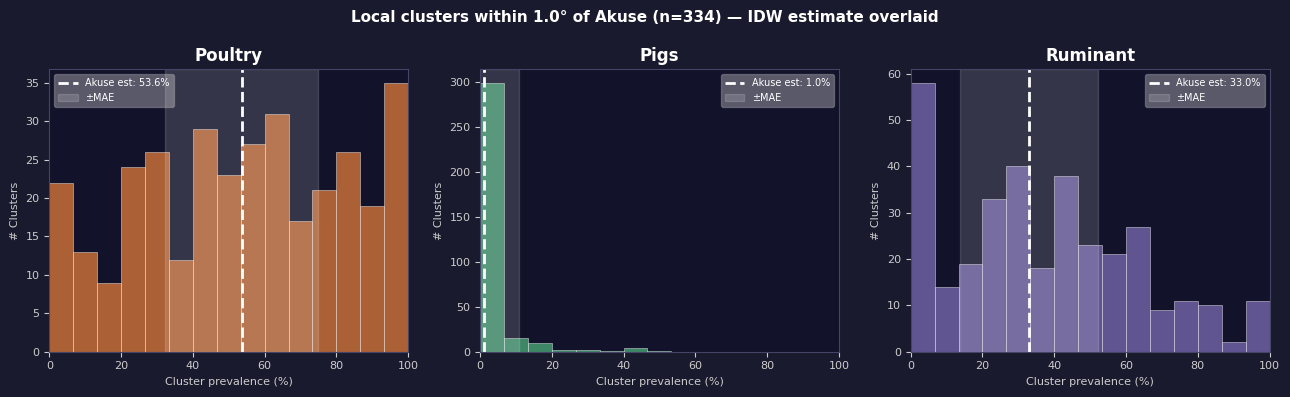

In [66]:
# ── Encode string → binary ────────────────────────────────────────────────
df['Poultry_bin']  = df['Poultry'].str.contains('Yes', case=False, na=False).astype(int)
df['Pigs_bin']     = df['Pigs'].str.contains('Yes', case=False, na=False).astype(int)
df['Ruminant_bin'] = df['Ruminant'].str.contains('Yes', case=False, na=False).astype(int)

animal_cols  = ['Poultry_bin', 'Pigs_bin', 'Ruminant_bin']
feature_cols = ['Education', 'Water', 'Sanitation', 'Crowding', 'Floors']

for col in feature_cols:
    if df[col].dtype == object:
        codes = pd.Categorical(df[col]).codes.astype(float)
        df[col] = np.where(codes == -1, np.nan, codes)

rural_mask = df['URBAN'].astype(str).str.contains('Rural', case=False, na=False)
cluster_stats = (
    df[rural_mask]
    .groupby(['Cluster', 'Latitude', 'Longitude'])[animal_cols + feature_cols]
    .mean()
    .reset_index()
)

AKUSE_CENTER = (0.1390, 6.0906)
CHOSEN_RADIUS = 1.0

# ── IDW ───────────────────────────────────────────────────────────────────
def idw_predict(train_df, target_lon, target_lat, power=2, radius=None):
    dx = train_df['Longitude'] - target_lon
    dy = train_df['Latitude']  - target_lat
    dists = np.sqrt(dx**2 + dy**2).clip(1e-10)
    if radius is not None and not np.isinf(radius):
        mask = dists <= radius
        train_df, dists = train_df[mask], dists[mask]
    if len(train_df) == 0:
        return {col: np.nan for col in animal_cols}
    weights = 1 / dists**power
    return {col: np.average(train_df[col], weights=weights) for col in animal_cols}

# ── Distances to Akuse ────────────────────────────────────────────────────
dx = cluster_stats['Longitude'] - AKUSE_CENTER[0]
dy = cluster_stats['Latitude']  - AKUSE_CENTER[1]
cluster_stats['dist_to_akuse'] = np.sqrt(dx**2 + dy**2)

n_local = (cluster_stats['dist_to_akuse'] <= CHOSEN_RADIUS).sum()
print(f"Rural clusters: {len(cluster_stats)}")
print(f"Clusters within {CHOSEN_RADIUS}° of Akuse: {n_local}")

# ── LOOCV at chosen radius ────────────────────────────────────────────────
errors = []
for idx, row in cluster_stats.iterrows():
    train     = cluster_stats.drop(idx)
    actual    = row[animal_cols].values.astype(float)
    pred      = idw_predict(train, row['Longitude'], row['Latitude'], radius=CHOSEN_RADIUS)
    pred_vals = np.array(list(pred.values()))
    if not np.any(np.isnan(pred_vals)):
        errors.append(np.abs(actual - pred_vals))

mae = np.mean(errors, axis=0)
mae_dict = dict(zip(animal_cols, mae))
print(f"\nMAE at {CHOSEN_RADIUS}°:")
for col, val in mae_dict.items():
    print(f"  {col}: {val:.3f}")

# ── Akuse estimate ────────────────────────────────────────────────────────
akuse_est = idw_predict(cluster_stats, *AKUSE_CENTER, radius=CHOSEN_RADIUS)

colors = {'Poultry_bin': '#e07b39', 'Pigs_bin': '#4caf7d', 'Ruminant_bin': '#7b6bb5'}
labels = {'Poultry_bin': 'Poultry', 'Pigs_bin': 'Pigs', 'Ruminant_bin': 'Ruminant'}

print(f"\n── Akuse Prevalence Estimates (radius={CHOSEN_RADIUS}°) ────────────")
for col in animal_cols:
    val = akuse_est[col]
    m   = mae_dict[col]
    print(f"  {labels[col]:10s}: {val:.3f}  ±{m:.3f}  "
          f"(95% CI: [{max(0, val-2*m):.3f}, {min(1, val+2*m):.3f}])")

# ── Plot: local clusters around Akuse ────────────────────────────────────
local = cluster_stats[cluster_stats['dist_to_akuse'] <= CHOSEN_RADIUS]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.patch.set_facecolor('#1a1a2e')

for ax, col in zip(axes, animal_cols):
    color = colors[col]
    est   = akuse_est[col]
    m     = mae_dict[col]

    ax.set_facecolor('#12122a')
    counts, edges = np.histogram(local[col] * 100, bins=15, range=(0, 100))
    ax.bar(edges[:-1], counts, width=np.diff(edges), color=color,
           alpha=0.75, edgecolor='white', linewidth=0.4, align='edge')
    ax.axvline(est * 100, color='white', linewidth=2, linestyle='--',
               label=f'Akuse est: {est*100:.1f}%')
    ax.axvspan((est - m) * 100, (est + m) * 100,
               alpha=0.15, color='white', label=f'±MAE')

    ax.set_title(labels[col], color='white', fontweight='bold')
    ax.set_xlabel('Cluster prevalence (%)', color='#cccccc', fontsize=8)
    ax.set_ylabel('# Clusters', color='#cccccc', fontsize=8)
    ax.tick_params(colors='#cccccc', labelsize=8)
    ax.legend(fontsize=7, labelcolor='white', framealpha=0.3)
    ax.set_xlim(0, 100)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')

fig.suptitle(f'Local clusters within {CHOSEN_RADIUS}° of Akuse (n={n_local}) — IDW estimate overlaid',
             color='white', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()